<a href="https://colab.research.google.com/github/explorerdorashen/ORF387-Networks-Final-Project/blob/main/ORF387_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Project Data.xlsx to Project Data.xlsx


In [ ]:
import networkx as nx
import pandas as pd

df = pd.read_excel("Project Data.xlsx", header=1)

# Drop rows with NaN values in 'Origin' or 'Destination' columns
df.dropna(subset=['Origin', 'Destination'], inplace=True)

G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(
        row['Origin'],
        row['Destination'],
        weight=row['Weight (# of flights in thousand)']
    )

In [ ]:
# Number of nodes and edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Average degree (in and out for directed graph)
# Sum of all in-degrees divided by number of nodes
sum_in_degrees = sum(dict(G.in_degree(weight='weight')).values())
avg_in_degree = sum_in_degrees / num_nodes if num_nodes > 0 else 0

# Sum of all out-degrees divided by number of nodes
sum_out_degrees = sum(dict(G.out_degree(weight='weight')).values())
avg_out_degree = sum_out_degrees / num_nodes if num_nodes > 0 else 0

# Density of the graph (for a directed graph)
# Formula: E / (V * (V - 1))
# G.density() also works for directed graphs
density = nx.density(G)

# Number of weakly connected components
num_wcc = nx.number_weakly_connected_components(G)

# Size of the largest weakly connected component
largest_wcc_size = len(max(nx.weakly_connected_components(G), key=len))

print(f"Network Summary Statistics:")
print(f"---------------------------")
print(f"Number of Nodes: {num_nodes}")
print(f"Number of Edges: {num_edges}")
print(f"Average weighted in-degree (total incoming traffic per node): {avg_in_degree:.2f}")
print(f"Average weighted out-degree (total outgoing traffic per node): {avg_out_degree:.2f}")
print(f"Graph Density: {density:.4f}")
print(f"Number of Weakly Connected Components: {num_wcc}")
print(f"Size of Largest Weakly Connected Component: {largest_wcc_size}")

Network Summary Statistics:
---------------------------
Number of Nodes: 39
Number of Edges: 300
Average weighted in-degree (total incoming traffic per node): 5153.86
Average weighted out-degree (total outgoing traffic per node): 5153.86
Graph Density: 0.2024
Number of Weakly Connected Components: 1
Size of Largest Weakly Connected Component: 39


Centrality Measures

In [ ]:
in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))
print('in_degree', in_degree)
print('out_degree', out_degree)

in_degree {'ATL': 19701.4, 'MCO': 12230.09, 'LGA': 8766.01, 'FLL': 5491.16, 'TPA': 1808.17, 'LAX': 15373.2, 'DFW': 16345.87, 'MIA': 6363.82, 'EWR': 6727.81, 'DEN': 17450.37, 'LAS': 10612.82, 'AUS': 0, 'PHX': 8872.22, 'ORD': 17948.25, 'SFO': 9952.66, 'IAH': 2526.93, 'BWI': 421.52, 'BOS': 6021.4400000000005, 'CLT': 4448.73, 'DCA': 1229.07, 'PHL': 2043.83, 'MDW': 0, 'DAL': 277.33, 'MSP': 1752.9, 'HOU': 252.65, 'MCI': 232.64, 'SEA': 7578.74, 'SLC': 1551.53, 'DTW': 1294.38, 'JFK': 5020.83, 'SAN': 3178.54, 'HNL': 1151.49, 'BNA': 275.96, 'SJU': 1634.51, 'PBI': 476.76, 'SMF': 546.57, 'SJC': 539.24, 'ANC': 900.95, 'IAD': 0}
out_degree {'ATL': 9905.67, 'MCO': 8870.8, 'LGA': 8023.14, 'FLL': 5711.35, 'TPA': 4780.78, 'LAX': 11139.89, 'DFW': 8779.8, 'MIA': 6725.81, 'EWR': 7306.09, 'DEN': 9532.61, 'LAS': 8399.58, 'AUS': 4373.25, 'PHX': 7846.26, 'ORD': 9792.59, 'SFO': 8744.12, 'IAH': 6516.83, 'BWI': 4272.17, 'BOS': 6514.86, 'CLT': 5561.92, 'DCA': 4716.21, 'PHL': 5536.7699999999995, 'MDW': 3236.47, 'DA

In [ ]:
import pandas as pd

# Convert in_degree dictionary to a DataFrame
in_degree_df = pd.DataFrame(in_degree.items(), columns=['Node', 'In-Degree Weight'])
# Sort in-degree results in descending order
in_degree_df = in_degree_df.sort_values(by='In-Degree Weight', ascending=False)

# Convert out_degree dictionary to a DataFrame
out_degree_df = pd.DataFrame(out_degree.items(), columns=['Node', 'Out-Degree Weight'])
# Sort out-degree results in descending order
out_degree_df = out_degree_df.sort_values(by='Out-Degree Weight', ascending=False)

print("In-Degree Results:")
display(in_degree_df)

print("\nOut-Degree Results:")
display(out_degree_df)

In-Degree Results:


,Node,In-Degree Weight
0,ATL,19701.40
13,ORD,17948.25
9,DEN,17450.37
6,DFW,16345.87
5,LAX,15373.20
1,MCO,12230.09
10,LAS,10612.82
14,SFO,9952.66
12,PHX,8872.22
2,LGA,8766.01



Out-Degree Results:


,Node,Out-Degree Weight
5,LAX,11139.89
0,ATL,9905.67
13,ORD,9792.59
9,DEN,9532.61
1,MCO,8870.80
6,DFW,8779.80
14,SFO,8744.12
10,LAS,8399.58
2,LGA,8023.14
26,SEA,8015.79


In [ ]:
pagerank = nx.pagerank(G, weight='weight', max_iter=200)
print('pagerank', pagerank)

pagerank {'ATL': 0.0736188912855463, 'MCO': 0.048572956580080415, 'LGA': 0.04319423031568306, 'FLL': 0.02571200056817508, 'TPA': 0.013514632770658532, 'LAX': 0.07064575919969293, 'DFW': 0.06873228826059838, 'MIA': 0.03128802835915681, 'EWR': 0.036799966521476164, 'DEN': 0.0704034782704407, 'LAS': 0.0488002690347484, 'AUS': 0.005401604965602128, 'PHX': 0.040735199085008826, 'ORD': 0.07350696781597173, 'SFO': 0.046426656095668775, 'IAH': 0.016372904129350392, 'BWI': 0.007014656279436246, 'BOS': 0.02482157800660151, 'CLT': 0.019352358100495577, 'DCA': 0.009772723489321905, 'PHL': 0.012137277209277538, 'MDW': 0.005401604965602128, 'DAL': 0.005795031114203051, 'MSP': 0.013975312428572221, 'HOU': 0.005760019549109225, 'MCI': 0.005731632943860948, 'SEA': 0.03911370622376796, 'SLC': 0.013942722376358047, 'DTW': 0.010192856025183846, 'JFK': 0.028917767319180908, 'SAN': 0.018973712355190235, 'HNL': 0.011608590852898228, 'BNA': 0.0058876696952303515, 'SJU': 0.012228502613140254, 'PBI': 0.00744280

In [ ]:
import pandas as pd

pagerank_df = pd.DataFrame(pagerank.items(), columns=['Node', 'PageRank Score'])
# Sort PageRank results in descending order
pagerank_df = pagerank_df.sort_values(by='PageRank Score', ascending=False)

print("PageRank Results:")
display(pagerank_df)

PageRank Results:


,Node,PageRank Score
0,ATL,0.073619
13,ORD,0.073507
5,LAX,0.070646
9,DEN,0.070403
6,DFW,0.068732
10,LAS,0.048800
1,MCO,0.048573
14,SFO,0.046427
2,LGA,0.043194
12,PHX,0.040735


In [ ]:
# Convert flights → distances
for u, v, d in G.edges(data=True):
    d['distance'] = 1 / d['weight']

betweenness = nx.betweenness_centrality(G, weight='distance')
print('betweenness', betweenness)

betweenness {'ATL': 0.14082503556187767, 'MCO': 0.05832147937411095, 'LGA': 0.025604551920341397, 'FLL': 0.021337126600284497, 'TPA': 0.0, 'LAX': 0.06685633001422475, 'DFW': 0.015647226173541962, 'MIA': 0.01422475106685633, 'EWR': 0.023470839260312945, 'DEN': 0.07254623044096728, 'LAS': 0.014935988620199148, 'AUS': 0.0, 'PHX': 0.009246088193456615, 'ORD': 0.08890469416785207, 'SFO': 0.04125177809388336, 'IAH': 0.0, 'BWI': 0.0, 'BOS': 0.023470839260312945, 'CLT': 0.0, 'DCA': 0.01991465149359886, 'PHL': 0.0, 'MDW': 0.0, 'DAL': 0.0, 'MSP': 0.0, 'HOU': 0.0, 'MCI': 0.0, 'SEA': 0.02062588904694168, 'SLC': 0.0, 'DTW': 0.0, 'JFK': 0.007112375533428165, 'SAN': 0.04125177809388336, 'HNL': 0.0, 'BNA': 0.0, 'SJU': 0.0, 'PBI': 0.0, 'SMF': 0.0, 'SJC': 0.0, 'ANC': 0.0, 'IAD': 0.0}


In [ ]:
import pandas as pd

betweenness_df = pd.DataFrame(betweenness.items(), columns=['Node', 'Betweenness Centrality'])
# Sort Betweenness Centrality results in descending order
betweenness_df = betweenness_df.sort_values(by='Betweenness Centrality', ascending=False)

print("Betweenness Centrality Results:")
display(betweenness_df)

Betweenness Centrality Results:


,Node,Betweenness Centrality
0,ATL,0.140825
13,ORD,0.088905
9,DEN,0.072546
5,LAX,0.066856
1,MCO,0.058321
30,SAN,0.041252
14,SFO,0.041252
2,LGA,0.025605
17,BOS,0.023471
8,EWR,0.023471


In [ ]:
# Weakly connected component (recommended for directed graph)
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_cc = G.subgraph(largest_cc)

# Size
lcc_size = len(G_cc)

# Average shortest path (custom calculation for potentially non-strongly connected graph)
total_path_length = 0
num_reachable_pairs = 0

if len(G_cc.nodes) > 1:
    for source_node in G_cc.nodes():
        # Get all shortest paths from the current source node
        paths_from_source = nx.shortest_path_length(G_cc, source=source_node, weight='distance')
        for target_node, length in paths_from_source.items():
            if source_node != target_node: # Exclude self-loops
                total_path_length += length
                num_reachable_pairs += 1

    if num_reachable_pairs > 0:
        avg_path = total_path_length / num_reachable_pairs
    else:
        avg_path = 0.0 # No reachable pairs, or graph has <=1 node
else:
    avg_path = 0.0 # If 0 or 1 nodes, average path length is 0 (or undefined)

# Efficiency
def efficiency(G_arg):
    import itertools
    n = len(G_arg)
    if n <= 1: # Handle cases with 0 or 1 nodes
        return 0.0
    denom = n * (n - 1)
    total = 0
    for u, v in itertools.permutations(G_arg.nodes, 2):
        try:
            d = nx.shortest_path_length(G_arg, u, v, weight='distance')
            total += 1 / d
        except nx.NetworkXNoPath: # Catch specific exception if path does not exist
            pass # If no path, this pair contributes 0 to efficiency, which is correct
    return total / denom

eff = efficiency(G_cc)

### Random Node Removal Simulation and Evaluation

In [ ]:
def evaluate_graph_metrics(graph):
    """Evaluates and returns the LCC size, average shortest path, and efficiency of a graph."""
    import networkx as nx
    # Make sure the efficiency function is available in scope or passed as an argument
    # For this execution, we assume it's in the global scope from previous cells.

    if not graph.nodes():
        return 0, 0.0, 0.0

    # Weakly connected component (recommended for directed graph)
    largest_cc = max(nx.weakly_connected_components(graph), key=len)
    G_cc = graph.subgraph(largest_cc)

    # Size
    lcc_size = len(G_cc)

    # Average shortest path (custom calculation for potentially non-strongly connected graph)
    total_path_length = 0
    num_reachable_pairs = 0

    if len(G_cc.nodes) > 1:
        for source_node in G_cc.nodes():
            paths_from_source = nx.shortest_path_length(G_cc, source=source_node, weight='distance')
            for target_node, length in paths_from_source.items():
                if source_node != target_node: # Exclude self-loops
                    total_path_length += length
                    num_reachable_pairs += 1

        if num_reachable_pairs > 0:
            avg_path = total_path_length / num_reachable_pairs
        else:
            avg_path = 0.0 # No reachable pairs, or graph has <=1 node
    else:
        avg_path = 0.0 # If 0 or 1 nodes, average path length is 0 (or undefined)

    # Efficiency
    eff = efficiency(G_cc) # Assuming 'efficiency' function is accessible from previous cell

    return lcc_size, avg_path, eff


In [ ]:
import random
import numpy as np

# Define percentages of nodes to remove
percentages_to_remove = np.arange(0, 1.01, 0.05) # 0% to 100% in 5% increments

# Store results for random removal
random_lcc_sizes = []
random_avg_paths = []
random_efficiencies = []

original_G_nodes = list(G.nodes())
num_original_nodes = len(original_G_nodes)

# Evaluate initial graph metrics (0% removal)
initial_lcc_size, initial_avg_path, initial_eff = evaluate_graph_metrics(G)
random_lcc_sizes.append(initial_lcc_size)
random_avg_paths.append(initial_avg_path)
random_efficiencies.append(initial_eff)

# Simulate random node removal
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    num_nodes_to_remove = int(num_original_nodes * p)

    # Randomly select nodes for removal
    nodes_to_remove = random.sample(original_G_nodes, num_nodes_to_remove)

    # Create a copy of the graph and remove nodes
    G_attacked = G.copy()
    G_attacked.remove_nodes_from(nodes_to_remove)

    # Evaluate metrics for the attacked graph
    lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
    random_lcc_sizes.append(lcc_size)
    random_avg_paths.append(avg_path)
    random_efficiencies.append(eff)

print("Random Removal Simulation Complete.")

Random Removal Simulation Complete.


In [ ]:
import random
import numpy as np

# Number of simulation runs to smooth out the curves
num_runs = 100

# Store results for random removal (averaged over num_runs)
# These will overwrite the single-run results from previous random removal cell
random_lcc_sizes = []
random_avg_paths = []
random_efficiencies = []

# Evaluate initial graph metrics (0% removal) once, as it's deterministic
initial_lcc_size, initial_avg_path, initial_eff = evaluate_graph_metrics(G)
random_lcc_sizes.append(initial_lcc_size)
random_avg_paths.append(initial_avg_path)
random_efficiencies.append(initial_eff)

# Simulate random node removal for multiple runs and average the results
# percentages_to_remove is expected to be defined from a previous cell
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    current_p_lcc_sizes = []
    current_p_avg_paths = []
    current_p_efficiencies = []

    for _ in range(num_runs):
        num_nodes_to_remove = int(num_original_nodes * p)

        # Randomly select nodes for removal
        nodes_to_remove = random.sample(original_G_nodes, num_nodes_to_remove)

        # Create a copy of the graph and remove nodes
        G_attacked = G.copy()
        G_attacked.remove_nodes_from(nodes_to_remove)

        # Evaluate metrics for the attacked graph
        lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
        current_p_lcc_sizes.append(lcc_size)
        current_p_avg_paths.append(avg_path)
        current_p_efficiencies.append(eff)

    # Calculate average for the current percentage across all runs
    random_lcc_sizes.append(np.mean(current_p_lcc_sizes))
    random_avg_paths.append(np.mean(current_p_avg_paths))
    random_efficiencies.append(np.mean(current_p_efficiencies))

print(f"Random Removal Simulation (averaged over {num_runs} runs) complete. Run the plotting cells again to see the smoothed curves.")

Random Removal Simulation (averaged over 100 runs) complete. Run the plotting cells again to see the smoothed curves.


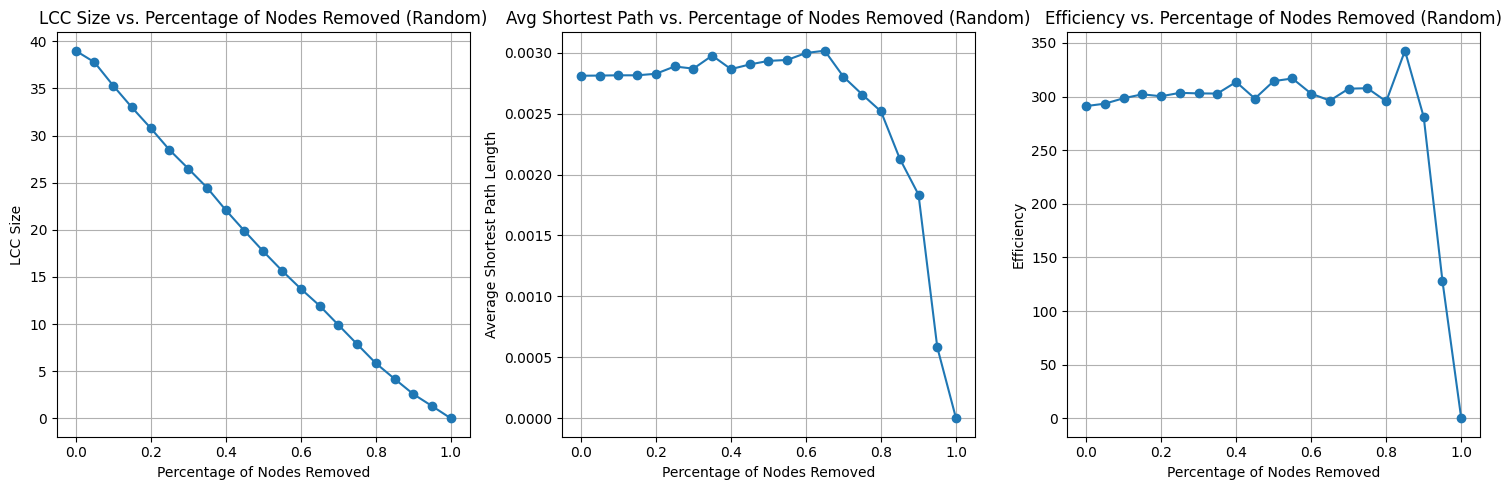

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Added import for numpy

# Define percentages of nodes to remove (moved here to resolve NameError)
percentages_to_remove = np.arange(0, 1.01, 0.05) # 0% to 100% in 5% increments

# Prepare percentages for plotting, ensuring it includes 0
percentages_for_plot = percentages_to_remove

plt.figure(figsize=(15, 5))

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-')
plt.title('LCC Size vs. Percentage of Nodes Removed (Random)')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed (Random)')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-')
plt.title('Efficiency vs. Percentage of Nodes Removed (Random)')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.grid(True)

plt.tight_layout()
plt.show()

### Targeted Node Removal Simulation (PageRank Attack) and Evaluation

In [ ]:
# Sort nodes by PageRank score in descending order
sorted_nodes = sorted(pagerank.keys(), key=lambda node: pagerank[node], reverse=True)

In [ ]:
# Store results for targeted removal
targeted_lcc_sizes = []
targeted_avg_paths = []
targeted_efficiencies = []

# Evaluate initial graph metrics (0% removal) - same as random, just append
targeted_lcc_sizes.append(initial_lcc_size)
targeted_avg_paths.append(initial_avg_path)
targeted_efficiencies.append(initial_eff)

# Simulate targeted node removal (PageRank attack)
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    num_nodes_to_remove = int(num_original_nodes * p)

    # Select nodes for removal based on PageRank (highest first)
    # Ensure we don't try to remove more nodes than available
    nodes_to_remove = sorted_nodes[:num_nodes_to_remove]

    # Create a copy of the graph and remove nodes
    G_attacked = G.copy()
    G_attacked.remove_nodes_from(nodes_to_remove)

    # Evaluate metrics for the attacked graph
    lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
    targeted_lcc_sizes.append(lcc_size)
    targeted_avg_paths.append(avg_path)
    targeted_efficiencies.append(eff)

print("Targeted Removal Simulation (PageRank) Complete.")

Targeted Removal Simulation (PageRank) Complete.


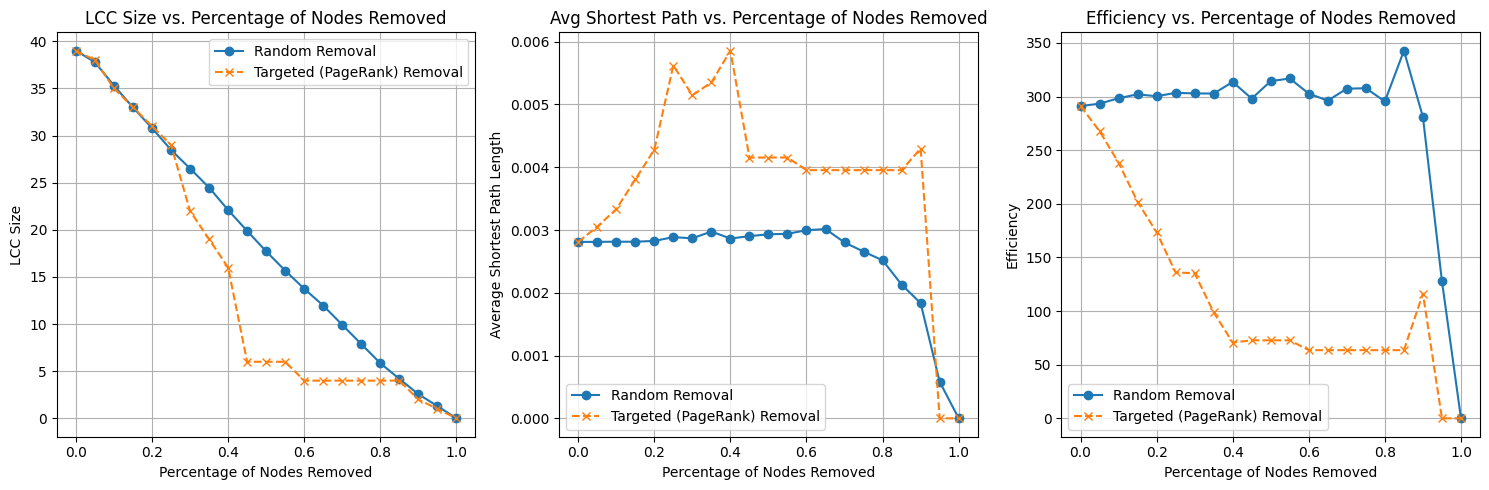

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_lcc_sizes, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.title('LCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.legend()
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_avg_paths, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.legend()
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_efficiencies, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Targeted Node Removal Simulation (Betweenness Centrality Attack) and Evaluation

In [ ]:
# Sort nodes by Betweenness Centrality score in descending order
sorted_nodes_by_betweenness = sorted(betweenness.keys(), key=lambda node: betweenness[node], reverse=True)

# Store results for betweenness-based targeted removal
betweenness_lcc_sizes = []
betweenness_avg_paths = []
betweenness_efficiencies = []

# Evaluate initial graph metrics (0% removal) - same as random, just append
betweenness_lcc_sizes.append(initial_lcc_size)
betweenness_avg_paths.append(initial_avg_path)
betweenness_efficiencies.append(initial_eff)

# Simulate targeted node removal (Betweenness centrality attack)
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    num_nodes_to_remove = int(num_original_nodes * p)

    # Select nodes for removal based on Betweenness Centrality (highest first)
    # Ensure we don't try to remove more nodes than available
    nodes_to_remove = sorted_nodes_by_betweenness[:num_nodes_to_remove]

    # Create a copy of the graph and remove nodes
    G_attacked = G.copy()
    G_attacked.remove_nodes_from(nodes_to_remove)

    # Evaluate metrics for the attacked graph
    lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
    betweenness_lcc_sizes.append(lcc_size)
    betweenness_avg_paths.append(avg_path)
    betweenness_efficiencies.append(eff)

print("Targeted Removal Simulation (Betweenness Centrality) Complete.")

Targeted Removal Simulation (Betweenness Centrality) Complete.


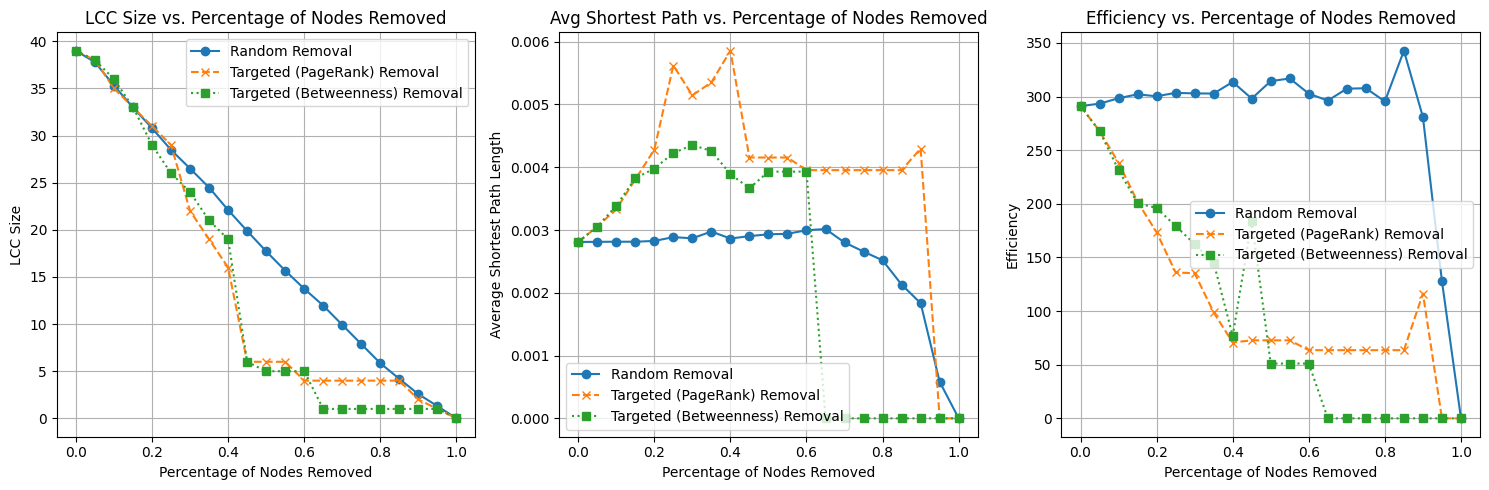

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_lcc_sizes, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_lcc_sizes, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.title('LCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.legend()
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_avg_paths, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_avg_paths, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.legend()
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_efficiencies, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_efficiencies, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Targeted Node Removal Simulation (In-degree Centrality Attack) and Evaluation

In [ ]:
# Sort nodes by In-Degree score in descending order
sorted_nodes_by_in_degree = sorted(in_degree.keys(), key=lambda node: in_degree[node], reverse=True)

# Store results for in-degree-based targeted removal
in_degree_lcc_sizes = []
in_degree_avg_paths = []
in_degree_efficiencies = []

# Evaluate initial graph metrics (0% removal) - same as random, just append
in_degree_lcc_sizes.append(initial_lcc_size)
in_degree_avg_paths.append(initial_avg_path)
in_degree_efficiencies.append(initial_eff)

# Simulate targeted node removal (In-Degree centrality attack)
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    num_nodes_to_remove = int(num_original_nodes * p)

    # Select nodes for removal based on In-Degree (highest first)
    # Ensure we don't try to remove more nodes than available
    nodes_to_remove = sorted_nodes_by_in_degree[:num_nodes_to_remove]

    # Create a copy of the graph and remove nodes
    G_attacked = G.copy()
    G_attacked.remove_nodes_from(nodes_to_remove)

    # Evaluate metrics for the attacked graph
    lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
    in_degree_lcc_sizes.append(lcc_size)
    in_degree_avg_paths.append(avg_path)
    in_degree_efficiencies.append(eff)

print("Targeted Removal Simulation (In-Degree Centrality) Complete.")

Targeted Removal Simulation (In-Degree Centrality) Complete.


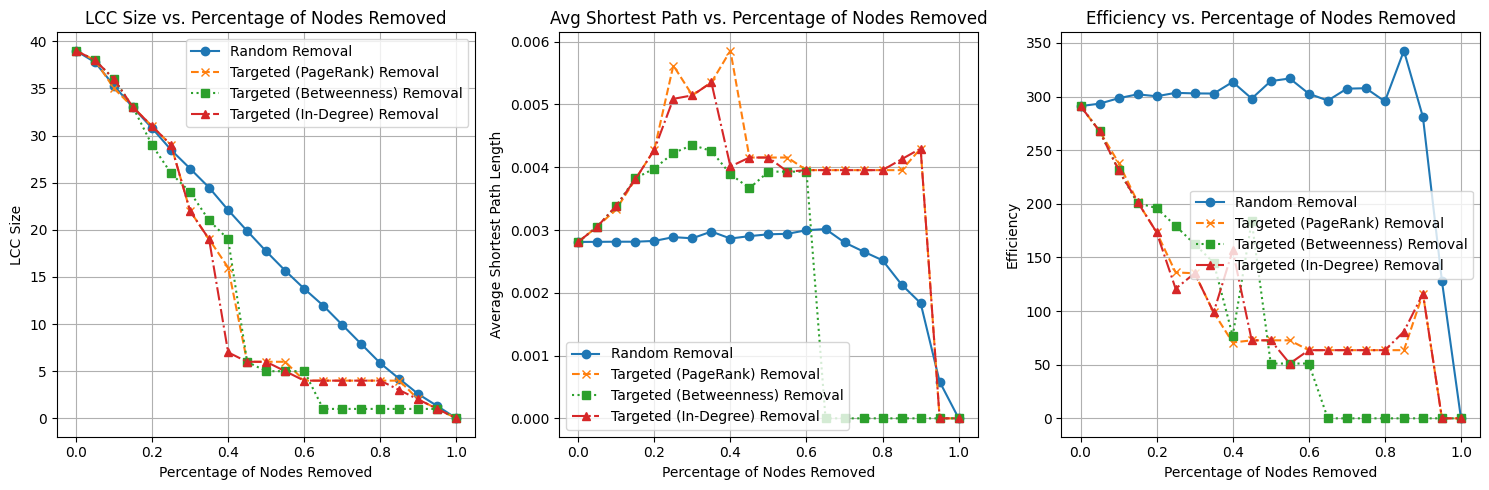

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_lcc_sizes, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_lcc_sizes, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_lcc_sizes, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.title('LCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.legend()
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_avg_paths, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_avg_paths, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_avg_paths, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.legend()
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_efficiencies, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_efficiencies, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_efficiencies, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Targeted Node Removal Simulation (Out-degree Centrality Attack) and Evaluation

---



In [ ]:
# Sort nodes by Out-Degree score in descending order
sorted_nodes_by_out_degree = sorted(out_degree.keys(), key=lambda node: out_degree[node], reverse=True)

# Store results for out-degree-based targeted removal
out_degree_lcc_sizes = []
out_degree_avg_paths = []
out_degree_efficiencies = []

# Evaluate initial graph metrics (0% removal) - same as random, just append
out_degree_lcc_sizes.append(initial_lcc_size)
out_degree_avg_paths.append(initial_avg_path)
out_degree_efficiencies.append(initial_eff)

# Simulate targeted node removal (Out-Degree centrality attack)
for p in percentages_to_remove[1:]: # Start from 5% as 0% is already evaluated
    num_nodes_to_remove = int(num_original_nodes * p)

    # Select nodes for removal based on Out-Degree (highest first)
    # Ensure we don't try to remove more nodes than available
    nodes_to_remove = sorted_nodes_by_out_degree[:num_nodes_to_remove]

    # Create a copy of the graph and remove nodes
    G_attacked = G.copy()
    G_attacked.remove_nodes_from(nodes_to_remove)

    # Evaluate metrics for the attacked graph
    lcc_size, avg_path, eff = evaluate_graph_metrics(G_attacked)
    out_degree_lcc_sizes.append(lcc_size)
    out_degree_avg_paths.append(avg_path)
    out_degree_efficiencies.append(eff)

print("Targeted Removal Simulation (Out-Degree Centrality) Complete.")

Targeted Removal Simulation (Out-Degree Centrality) Complete.


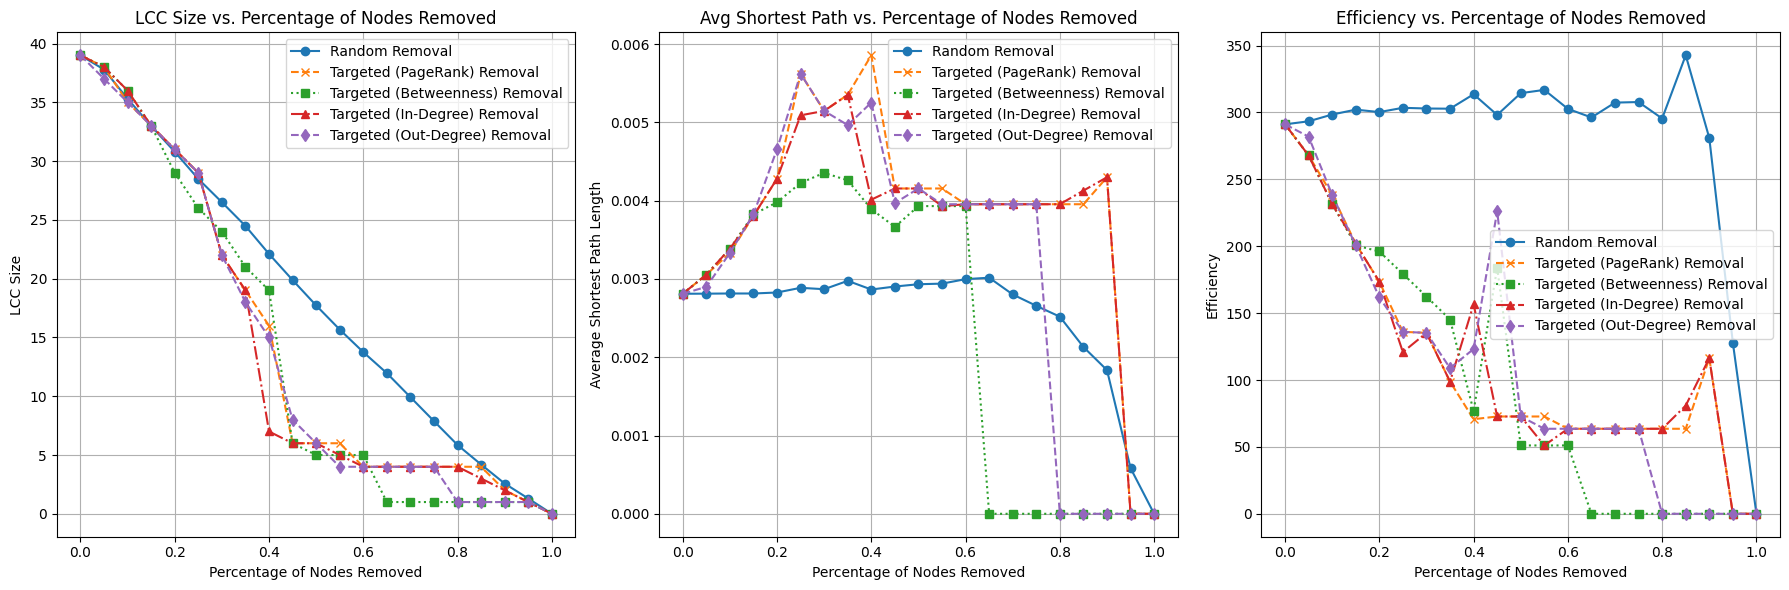

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure percentages_for_plot is defined
percentages_to_remove = np.arange(0, 1.01, 0.05)
percentages_for_plot = percentages_to_remove

plt.figure(figsize=(18, 6))

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_lcc_sizes, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_lcc_sizes, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_lcc_sizes, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_lcc_sizes, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
plt.title('LCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.legend()
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_avg_paths, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_avg_paths, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_avg_paths, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_avg_paths, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.legend()
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_efficiencies, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_efficiencies, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_efficiencies, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_efficiencies, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### NYC Area Attack

In [ ]:
import networkx as nx
import pandas as pd
import itertools

# NYC area attack nodes
nyc_attack_nodes = ['LGA', 'EWR', 'JFK']

G_nyc_attacked = G.copy()
G_nyc_attacked.remove_nodes_from(nyc_attack_nodes)

# Evaluate metrics for the NYC attacked graph
nyc_lcc_size, nyc_avg_path, nyc_efficiency = evaluate_graph_metrics(G_nyc_attacked)

# Calculate the percentage of nodes removed for this specific attack
nyc_percentage_removed = len(nyc_attack_nodes) / num_original_nodes

print(f"\nNYC Area Attack Simulation Results (Removed: {nyc_attack_nodes}):")
print(f"-----------------------------------------------------------------")
print(f"Percentage of Nodes Removed: {nyc_percentage_removed:.2%}")
print(f"LCC Size: {nyc_lcc_size}")
print(f"Average Shortest Path: {nyc_avg_path:.4f}")
print(f"Efficiency: {nyc_efficiency:.4f}")


NYC Area Attack Simulation Results (Removed: ['LGA', 'EWR', 'JFK']):
-----------------------------------------------------------------
Percentage of Nodes Removed: 7.69%
LCC Size: 35
Average Shortest Path: 0.0029
Efficiency: 277.9015


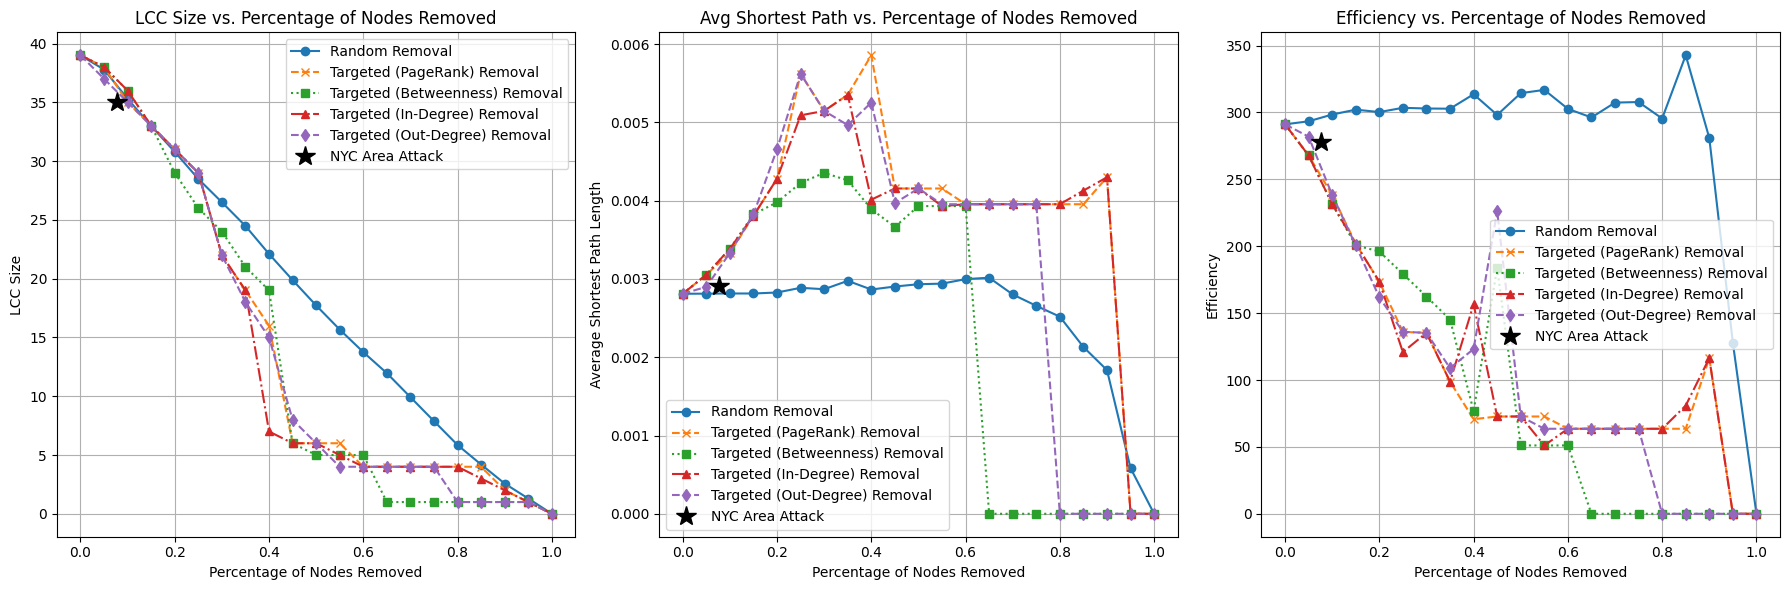

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Added import for numpy

# Re-define percentages_for_plot to ensure it's available
percentages_to_remove = np.arange(0, 1.01, 0.05)
percentages_for_plot = percentages_to_remove

plt.figure(figsize=(18, 6)) # Increased figure size for better readability with more plots

# Plot Largest Connected Component Size
plt.subplot(1, 3, 1)
plt.plot(percentages_for_plot, random_lcc_sizes, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_lcc_sizes, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_lcc_sizes, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_lcc_sizes, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_lcc_sizes, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
# Add NYC Area Attack results to LCC plot
plt.plot(nyc_percentage_removed, nyc_lcc_size, marker='*', markersize=15, color='black', label='NYC Area Attack', linestyle='None')
plt.title('LCC Size vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('LCC Size')
plt.legend()
plt.grid(True)

# Plot Average Shortest Path Length
plt.subplot(1, 3, 2)
plt.plot(percentages_for_plot, random_avg_paths, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_avg_paths, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_avg_paths, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_avg_paths, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_avg_paths, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
# Add NYC Area Attack results to Avg Shortest Path plot
plt.plot(nyc_percentage_removed, nyc_avg_path, marker='*', markersize=15, color='black', label='NYC Area Attack', linestyle='None')
plt.title('Avg Shortest Path vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Shortest Path Length')
plt.legend()
plt.grid(True)

# Plot Efficiency
plt.subplot(1, 3, 3)
plt.plot(percentages_for_plot, random_efficiencies, marker='o', linestyle='-', label='Random Removal')
plt.plot(percentages_for_plot, targeted_efficiencies, marker='x', linestyle='--', label='Targeted (PageRank) Removal')
plt.plot(percentages_for_plot, betweenness_efficiencies, marker='s', linestyle=':', label='Targeted (Betweenness) Removal')
plt.plot(percentages_for_plot, in_degree_efficiencies, marker='^', linestyle='-.', label='Targeted (In-Degree) Removal')
plt.plot(percentages_for_plot, out_degree_efficiencies, marker='d', linestyle='--', label='Targeted (Out-Degree) Removal')
# Add NYC Area Attack results to Efficiency plot
plt.plot(nyc_percentage_removed, nyc_efficiency, marker='*', markersize=15, color='black', label='NYC Area Attack', linestyle='None')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()